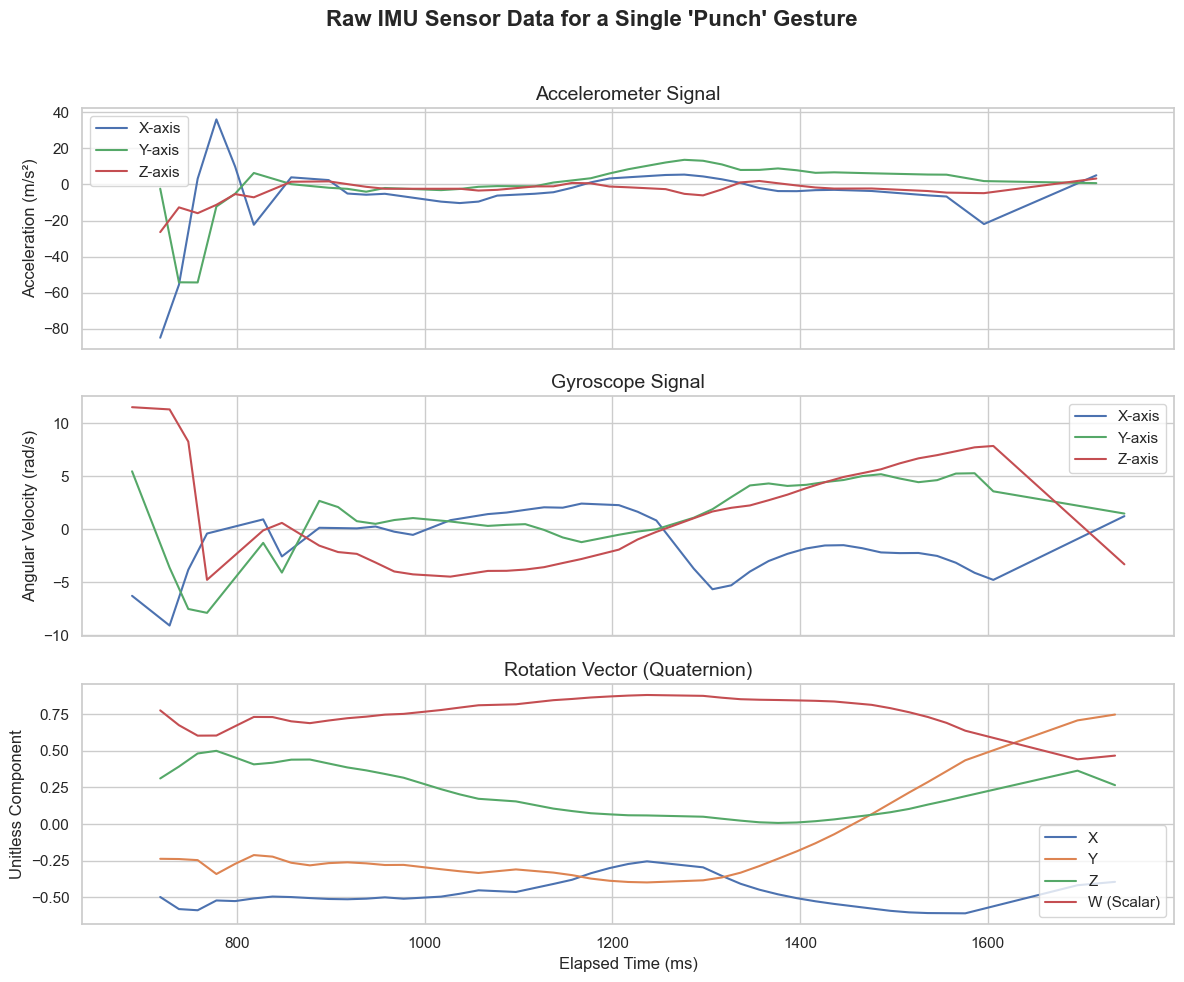

In [5]:
# Figure 1.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
file_path = Path("data/button_collected/punch_1760861137264_to_1760861138638.csv")

# --- Data Loading and Preprocessing ---

# Load the raw, unmerged data from the CSV
df = pd.read_csv(file_path)

# The raw timestamp is in nanoseconds. Convert it to a more readable
# "elapsed time in milliseconds" format for the x-axis.
start_time = df["timestamp"].min()
df["elapsed_ms"] = (df["timestamp"] - start_time) / 1_000_000

# The data is "sparse" - each row only contains data for one sensor.
# We filter the DataFrame into three separate ones for plotting.
accel_df = df[df["sensor"] == "linear_acceleration"].copy()
gyro_df = df[df["sensor"] == "gyroscope"].copy()
rot_df = df[df["sensor"] == "rotation_vector"].copy()

# --- Visualization ---
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots stacked vertically.
# `sharex=True` links the x-axes, making comparison easy.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

# Plot 1: Accelerometer Data
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_x",
    ax=axes[0],
    label="X-axis",
    color="b",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_y",
    ax=axes[0],
    label="Y-axis",
    color="g",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_z",
    ax=axes[0],
    label="Z-axis",
    color="r",
)
axes[0].set_title("Accelerometer Signal", fontsize=14)
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()

# Plot 2: Gyroscope Data
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_x", ax=axes[1], label="X-axis", color="b"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_y", ax=axes[1], label="Y-axis", color="g"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_z", ax=axes[1], label="Z-axis", color="r"
)
axes[1].set_title("Gyroscope Signal", fontsize=14)
axes[1].set_ylabel("Angular Velocity (rad/s)")
axes[1].legend()

# Plot 3: Rotation Vector Data
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_x", ax=axes[2], label="X")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_y", ax=axes[2], label="Y")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_z", ax=axes[2], label="Z")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_w", ax=axes[2], label="W (Scalar)")
axes[2].set_title("Rotation Vector (Quaternion)", fontsize=14)
axes[2].set_ylabel("Unitless Component")
axes[2].set_xlabel("Elapsed Time (ms)", fontsize=12)
axes[2].legend()

# Add a main title for the entire figure
fig.suptitle(
    "Raw IMU Sensor Data for a Single 'Punch' Gesture",
    fontsize=16,
    fontweight="bold",
)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the final plot
plt.show()

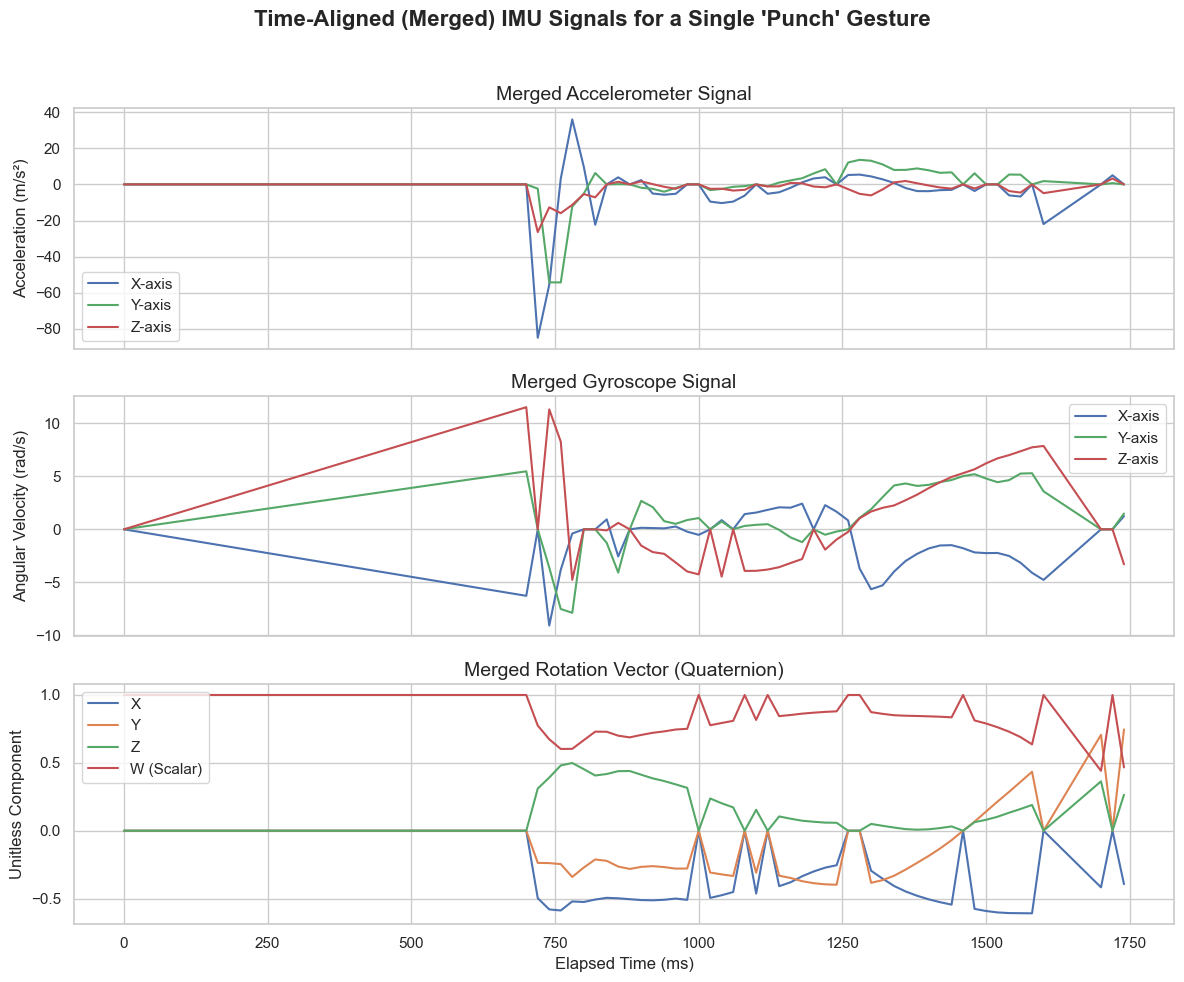

In [3]:
# Figure 1.2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
# TODO: Update this path to the location of your MERGED data file.
file_path = Path(
    "/Users/cvk/Downloads/CODELocalProjects/v3pls/data/merged_training/punch_1760861137264_to_1760861138638.csv"
)

# --- Data Loading and Preprocessing ---
try:
    # Load the merged data from the CSV
    df = pd.read_csv(file_path)

    # The raw timestamp is in nanoseconds. Convert it to a more readable
    # "elapsed time in milliseconds" format for the x-axis.
    if "timestamp" in df.columns:
        start_time = df["timestamp"].min()
        df["elapsed_ms"] = (df["timestamp"] - start_time) / 1_000_000
        x_axis = "elapsed_ms"
    else:
        # Fallback if there's no timestamp column, just use the index
        x_axis = df.index
        print("Warning: 'timestamp' column not found. Using index for x-axis.")

    # --- Visualization ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

    # Plot 1: Accelerometer Data (Merged)
    sns.lineplot(data=df, x=x_axis, y="accel_x", ax=axes[0], label="X-axis", color="b")
    sns.lineplot(data=df, x=x_axis, y="accel_y", ax=axes[0], label="Y-axis", color="g")
    sns.lineplot(data=df, x=x_axis, y="accel_z", ax=axes[0], label="Z-axis", color="r")
    axes[0].set_title("Merged Accelerometer Signal", fontsize=14)
    axes[0].set_ylabel("Acceleration (m/s²)")
    axes[0].legend()

    # Plot 2: Gyroscope Data (Merged)
    sns.lineplot(data=df, x=x_axis, y="gyro_x", ax=axes[1], label="X-axis", color="b")
    sns.lineplot(data=df, x=x_axis, y="gyro_y", ax=axes[1], label="Y-axis", color="g")
    sns.lineplot(data=df, x=x_axis, y="gyro_z", ax=axes[1], label="Z-axis", color="r")
    axes[1].set_title("Merged Gyroscope Signal", fontsize=14)
    axes[1].set_ylabel("Angular Velocity (rad/s)")
    axes[1].legend()

    # Plot 3: Rotation Vector Data (Merged)
    sns.lineplot(data=df, x=x_axis, y="rot_x", ax=axes[2], label="X")
    sns.lineplot(data=df, x=x_axis, y="rot_y", ax=axes[2], label="Y")
    sns.lineplot(data=df, x=x_axis, y="rot_z", ax=axes[2], label="Z")
    sns.lineplot(data=df, x=x_axis, y="rot_w", ax=axes[2], label="W (Scalar)")
    axes[2].set_title("Merged Rotation Vector (Quaternion)", fontsize=14)
    axes[2].set_ylabel("Unitless Component")
    axes[2].set_xlabel(
        "Elapsed Time (ms)" if x_axis == "elapsed_ms" else "Sample Index", fontsize=12
    )
    axes[2].legend()

    fig.suptitle(
        "Time-Aligned (Merged) IMU Signals for a Single 'Punch' Gesture",
        fontsize=16,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

except FileNotFoundError:
    print(f"--- ERROR: Data file not found at '{file_path}' ---")
    print(
        "Please update the 'file_path' variable in the code cell to point to your MERGED CSV file."
    )